# Stage 09 — Feature Engineering

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# === Synthetic data generator ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,East,46.3,29082.70,3,137.56
1,2021-02-02,West,31.8,NaN,1,96.23
2,2021-02-03,West,31.4,29233.77,5,140.45
3,2021-02-04,South,42.3,43300.48,4,168.46
4,2021-02-05,West,44.6,49606.70,2,95.54


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[us]
 1   region        160 non-null    str           
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 8.3 KB


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   income         100 non-null    int64
 1   monthly_spend  100 non-null    int64
 2   credit_score   100 non-null    int64
 3   region         100 non-null    str  
 4   default_flag   100 non-null    int64
dtypes: int64(4), str(1)
memory usage: 4.5 KB


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [7]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df["log_transactions"] = np.log1p(df["transactions"])

### Rationale for Feature 1
EDA insight: Stage 08 showed that transactions is strongly right-skewed and contains several extreme values.
Rationale: I applied a log transformation to reduce skewness and compress the influence of very large transaction values. This may make the relationship with the target easier to model.

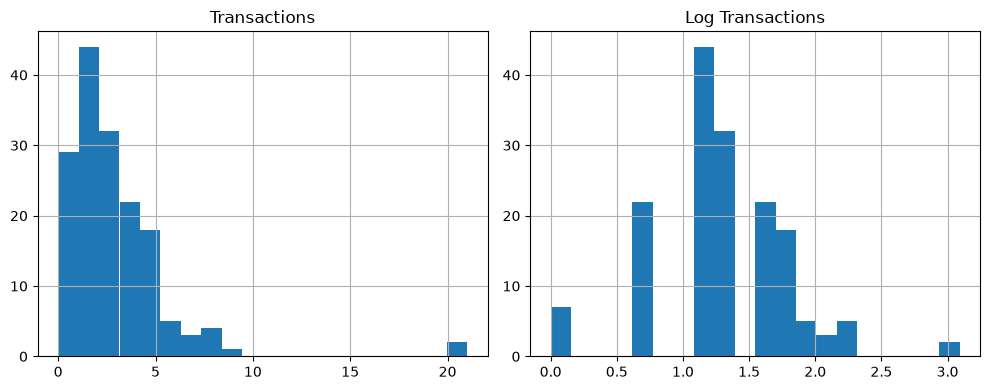

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["transactions"].hist(ax=axes[0], bins=20)
axes[0].set_title("Transactions")

df["log_transactions"].hist(ax=axes[1], bins=20)
axes[1].set_title("Log Transactions")

plt.tight_layout()
plt.show()

In [9]:
# Worked example 2 of 3
df["spend_per_transaction"] = (
    df["spend"] / df["transactions"].replace(0, np.nan)
)

### Rationale for Feature 2
EDA insight: Stage 08 showed a strong positive relationship between spend and transactions.
Rationale: I created spend_per_transaction to separate overall spending volume from transaction frequency. It measures the average amount spent per transaction and may reveal customer behavior that is not captured by either raw variable alone.

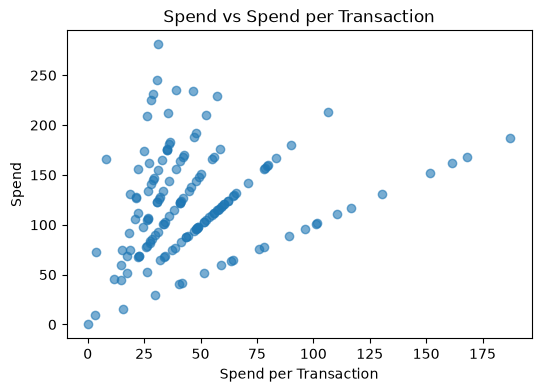

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df["spend_per_transaction"], df["spend"], alpha=0.6)
plt.xlabel("Spend per Transaction")
plt.ylabel("Spend")
plt.title("Spend vs Spend per Transaction")
plt.show()

In [11]:
# Worked example 3 of 3
df["spend_7d_mean"] = df["spend"].rolling(window=7).mean()

### Rationale for Feature 3
EDA insight: Stage 08 showed substantial day-to-day variation in spend, while the 7-day rolling average was much more stable.
Rationale: I created a 7-day rolling mean to smooth short-term fluctuations and capture the recent local spending level.

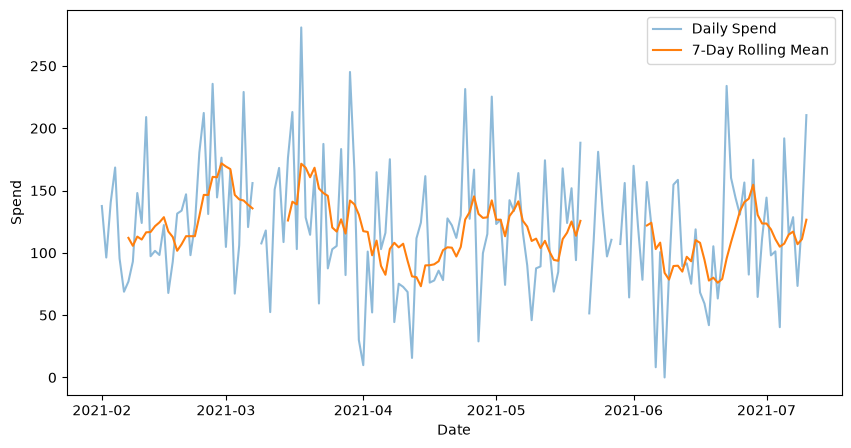

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(df["date"], df["spend"], label="Daily Spend", alpha=0.5)
plt.plot(df["date"], df["spend_7d_mean"], label="7-Day Rolling Mean")

plt.xlabel("Date")
plt.ylabel("Spend")
plt.legend()
plt.show()

In [13]:
# Categorical encoding
region_freq = df["region"].value_counts(normalize=True)
df["region_freq"] = df["region"].map(region_freq)

### Rationale for Feature 4
Rationale: region is categorical and cannot be used directly by many numerical models. I used frequency encoding to convert each region into the proportion of observations belonging to that category while keeping the feature compact.

In [15]:
region_summary = (
    df.groupby("region")
      .agg(
          avg_spend=("spend", "mean"),
          region_freq=("region_freq", "first")
      )
      .reset_index()
)

region_summary

,region,avg_spend,region_freq
0,East,118.261026,0.2500
1,North,127.141860,0.2750
2,South,116.155333,0.1875
3,West,115.166000,0.2875


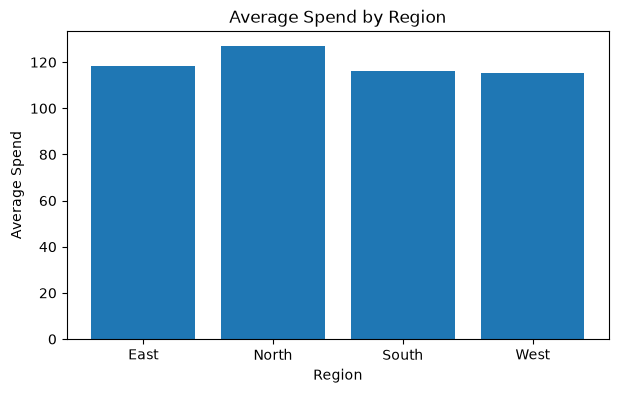

In [16]:
plt.figure(figsize=(7, 4))
plt.bar(region_summary["region"], region_summary["avg_spend"])
plt.xlabel("Region")
plt.ylabel("Average Spend")
plt.title("Average Spend by Region")
plt.show()